# Data Visualization

**Data Science for Research Assistants**

This notebook covers data visualization in Python using matplotlib and seaborn. By the end, you'll be able to create effective visualizations for exploring and communicating data.

## How to Use This Notebook

- Run each cell by pressing `Shift + Enter`
- Feel free to modify the code and experiment
- If something breaks, you can restart the kernel from the menu and run cells again

---
## Setup

We use three main libraries for visualization:

- **matplotlib**: The foundational plotting library in Python
- **seaborn**: A statistical visualization library built on matplotlib with cleaner syntax
- **pandas**: Built-in plotting capabilities for DataFrames

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_style("whitegrid")

---
## Loading the Data

We'll use the Star Wars characters dataset, which contains information about 87 characters from the Star Wars universe.

In [2]:
starwars = pd.read_csv("../data/star_wars.csv", na_values= "na")

In [3]:
starwars.shape

(87, 14)

In [4]:
starwars.tail(10)

,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
77,Grievous,216.0,159.0,none,"brown, white","green, yellow",NaN,male,masculine,Kalee,Kaleesh,Revenge of the Sith,Tsmeu-6 personal wheel bike,Belbullab-22 starfighter
78,Tarfful,234.0,136.0,brown,brown,blue,NaN,male,masculine,Kashyyyk,Wookiee,Revenge of the Sith,NaN,NaN
79,Raymus Antilles,188.0,79.0,brown,light,brown,NaN,male,masculine,Alderaan,Human,"A New Hope, Revenge of the Sith",NaN,NaN
80,Sly Moore,178.0,48.0,none,pale,white,NaN,NaN,NaN,Umbara,NaN,"Attack of the Clones, Revenge of the Sith",NaN,NaN
81,Tion Medon,206.0,80.0,none,grey,black,NaN,male,masculine,Utapau,Pau'an,Revenge of the Sith,NaN,NaN
82,Finn,NaN,NaN,black,dark,dark,NaN,male,masculine,NaN,Human,The Force Awakens,NaN,NaN
83,Rey,NaN,NaN,brown,light,hazel,NaN,female,feminine,NaN,Human,The Force Awakens,NaN,NaN
84,Poe Dameron,NaN,NaN,brown,light,brown,NaN,male,masculine,NaN,Human,The Force Awakens,NaN,X-wing
85,BB8,NaN,NaN,none,none,black,NaN,none,masculine,NaN,Droid,The Force Awakens,NaN,NaN
86,Captain Phasma,NaN,NaN,none,none,unknown,NaN,female,feminine,NaN,Human,The Force Awakens,NaN,NaN


---
## Scatter Plots

Scatter plots show the relationship between two continuous variables. Use `sns.scatterplot()` to create them.

Text(0.5, 1.0, 'Star Wars Mass vs Height')

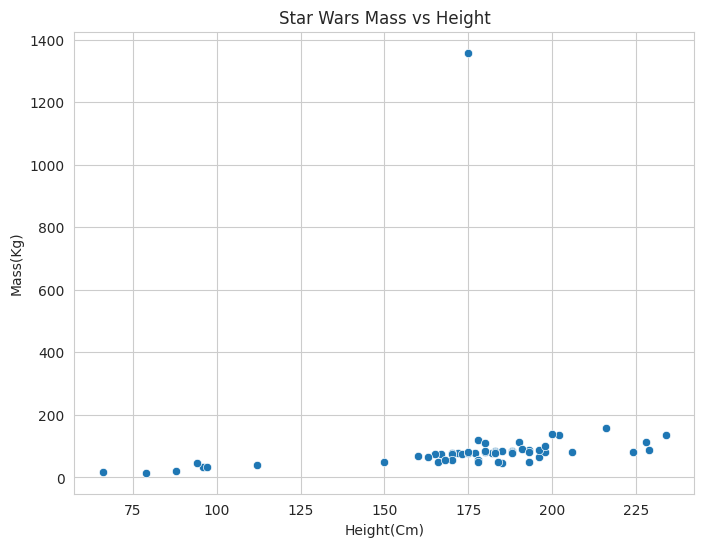

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=starwars, x ="height", y="mass")
plt.xlabel("Height(Cm)") 
plt.ylabel("Mass(Kg)")
plt.title("Star Wars Mass vs Height")


Notice the outlier with mass over 1000 kg. Let's identify who that is.

In [6]:
index_of_heaviest = starwars["mass"].idxmax()
starwars.iloc[index_of_heaviest]

name                                      Jabba Desilijic Tiure
height                                                    175.0
mass                                                     1358.0
hair_color                                                  NaN
skin_color                                     green-tan, brown
eye_color                                                orange
birth_year                                                600.0
sex                                              hermaphroditic
gender                                                masculine
homeworld                                             Nal Hutta
species                                                    Hutt
films         A New Hope, Return of the Jedi, The Phantom Me...
vehicles                                                    NaN
starships                                                   NaN
Name: 15, dtype: object

Jabba the Hutt! Visualization helps identify outliers and unusual data points.

---
## Aesthetic Mappings

**Aesthetics** are visual properties of plot elements. You can map data variables to aesthetics like:

| Aesthetic | Parameter | Example |
|-----------|-----------|----------|
| Color | `hue` | Different colors for different categories |
| Size | `size` | Different sizes for different values |
| Shape | `style` | Different marker shapes |

Text(0.5, 1.0, 'Star Wars Mass vs Height, Colored by sex')

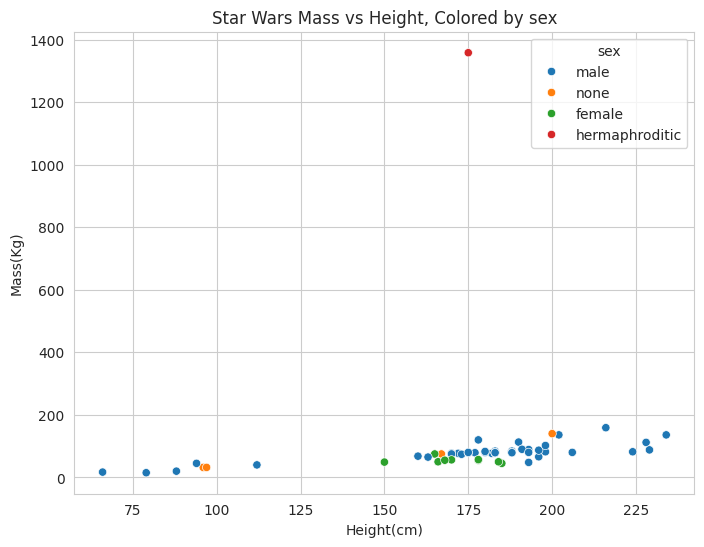

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=starwars, x="height", y="mass", hue="sex")
plt.xlabel("Height(cm)") 
plt.ylabel("Mass(Kg)")
plt.title("Star Wars Mass vs Height, Colored by sex")


Let's filter out Jabba for better visualization of the main data.

In [8]:
starwars_filtered = starwars[starwars["mass"] < 500]

In [9]:
starwars.isna().sum()

name           0
height         6
mass          28
hair_color     5
skin_color     0
eye_color      0
birth_year    44
sex            4
gender         4
homeworld     10
species        4
films          0
vehicles      76
starships     67
dtype: int64

In [10]:
starwars_filtered.shape

(58, 14)

Text(0.5, 1.0, 'Star Wars Mass vs Height, Colored by sex')

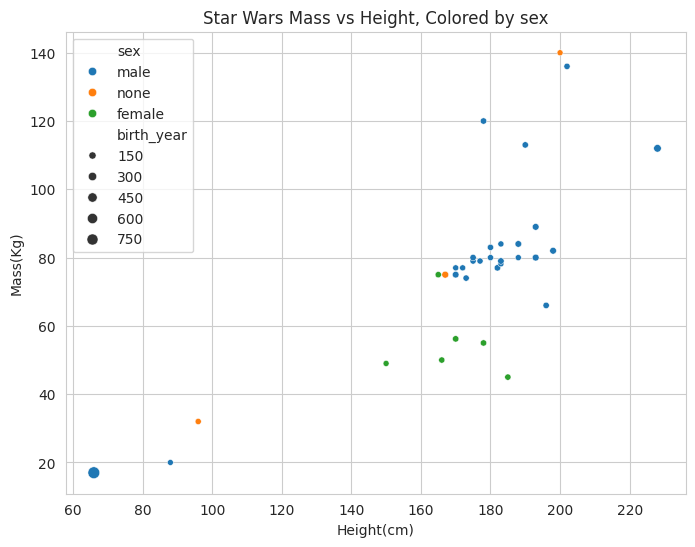

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=starwars_filtered, x="height", y="mass", hue="sex", size="birth_year")
plt.xlabel("Height(cm)") 
plt.ylabel("Mass(Kg)")
plt.title("Star Wars Mass vs Height, Colored by sex")

---
## Histograms

Histograms show the distribution of a single continuous variable by dividing the data into bins.

Text(0, 0.5, 'Count')

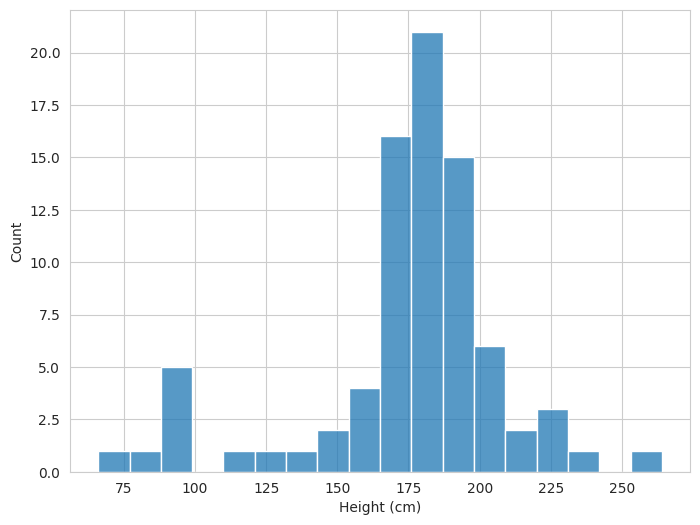

In [12]:
plt.figure(figsize=(8,6))
sns.histplot(data=starwars, x="height")
plt.xlabel("Height (cm)")
plt.ylabel("Count")

You can adjust the bin width to change the granularity.

### Describing Distributions

When describing the shape of a distribution, consider:

- **Skewness**: right-skewed, left-skewed, or symmetric
- **Modality**: unimodal (one peak), bimodal (two peaks), or multimodal
- **Center**: mean, median
- **Spread**: range, standard deviation
- **Outliers**: unusual observations

---
## Density Plots

Density plots (kernel density estimation) show a smoothed version of the histogram.

Text(0, 0.5, 'Density')

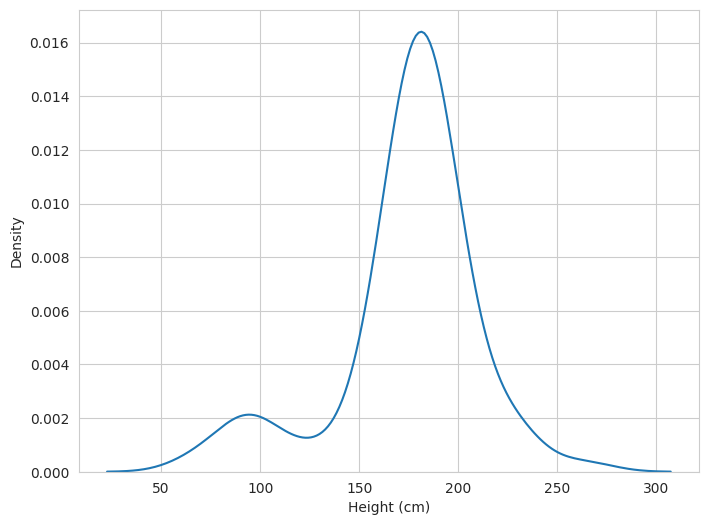

In [13]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=starwars, x="height")
plt.xlabel("Height (cm)")
plt.ylabel("Density")

You can overlay a density curve on a histogram with `kde=True`.

Text(0, 0.5, 'Count')

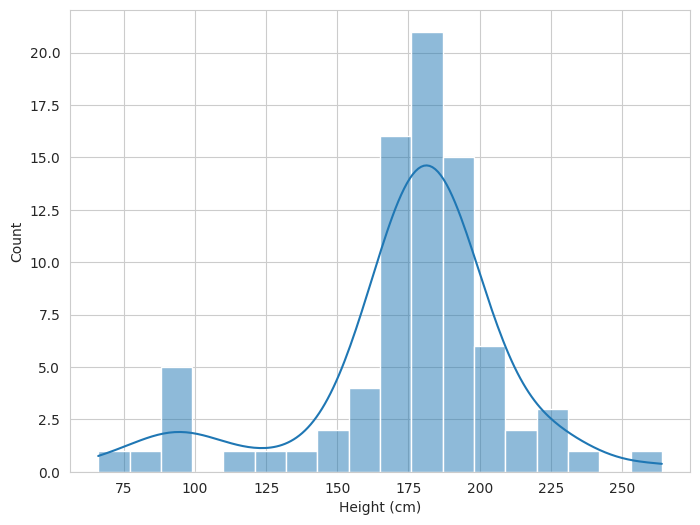

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(data=starwars, x="height", kde= True)
plt.xlabel("Height (cm)")
plt.ylabel("Count")

---
## Bar Plots

Bar plots show counts of categorical variables. Use `sns.countplot()` to create them.

Text(0, 0.5, 'Count')

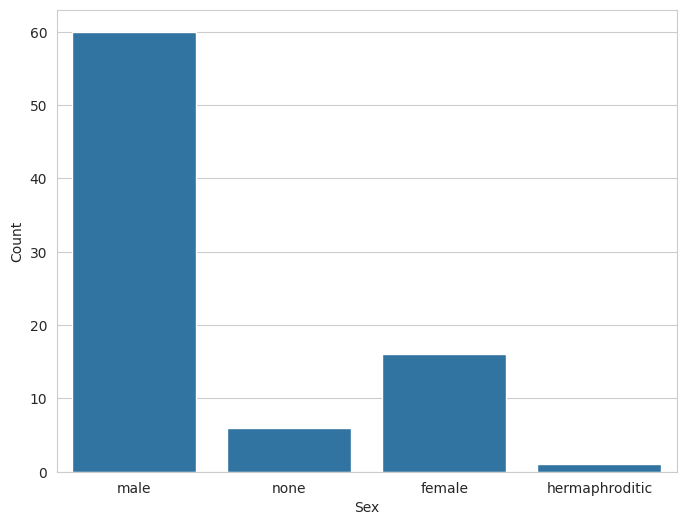

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(data=starwars, x="sex")
plt.xlabel("Sex")
plt.ylabel("Count")

You can order the bars by count using the `order` parameter.

In [17]:
sex_order = starwars["sex"].value_counts().index

Text(0, 0.5, 'Count')

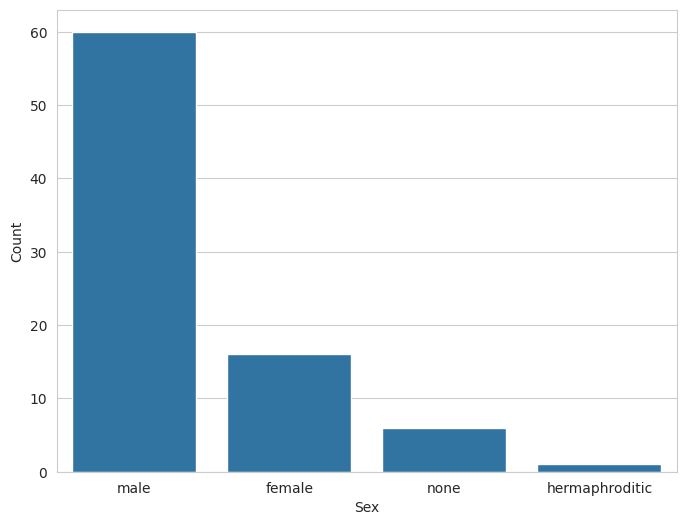

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(data=starwars, x="sex", order= sex_order)
plt.xlabel("Sex")
plt.ylabel("Count")

---
## Box Plots

Box plots show the distribution of a numerical variable, optionally grouped by a category. They're useful for comparing distributions across groups.

<Axes: xlabel='sex', ylabel='height'>

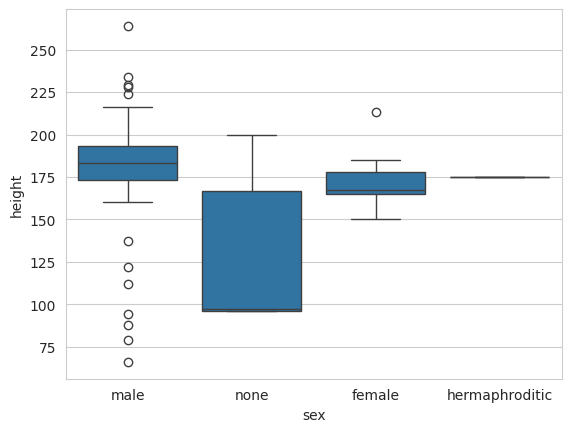

In [19]:
sns.boxplot (data=starwars, x="sex", y="height")

**Understanding Box Plots:**

- The box shows the interquartile range (IQR): 25th to 75th percentile
- The line inside the box is the median (50th percentile)
- Whiskers extend to 1.5 × IQR from the box
- Points beyond the whiskers are potential outliers

---
## Choosing the Right Plot

The type of plot depends on your variables:

| Y Variable | X Variable | Recommended Plot |
|------------|------------|------------------|
| Continuous | Continuous | `scatterplot()` |
| Continuous | Categorical | `boxplot()` |
| Categorical | — | `countplot()` |
| Continuous | — | `histplot()`, `kdeplot()` |

---
## Faceting

**Faceting** creates multiple small plots that display different subsets of the data. Use the `col` parameter in seaborn's plot functions.

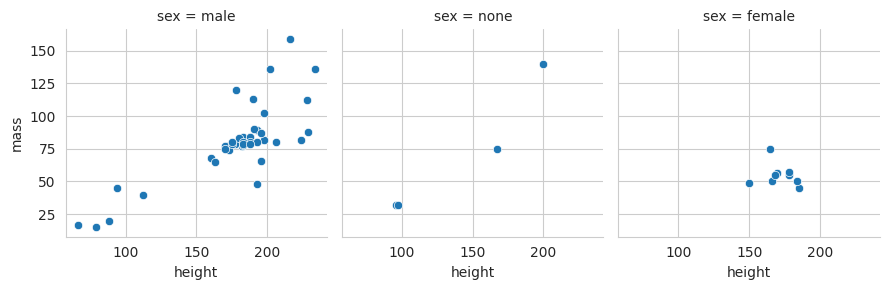

In [20]:
sns.relplot(data=starwars_filtered, x="height", y="mass", col="sex", col_wrap=3, height=3)

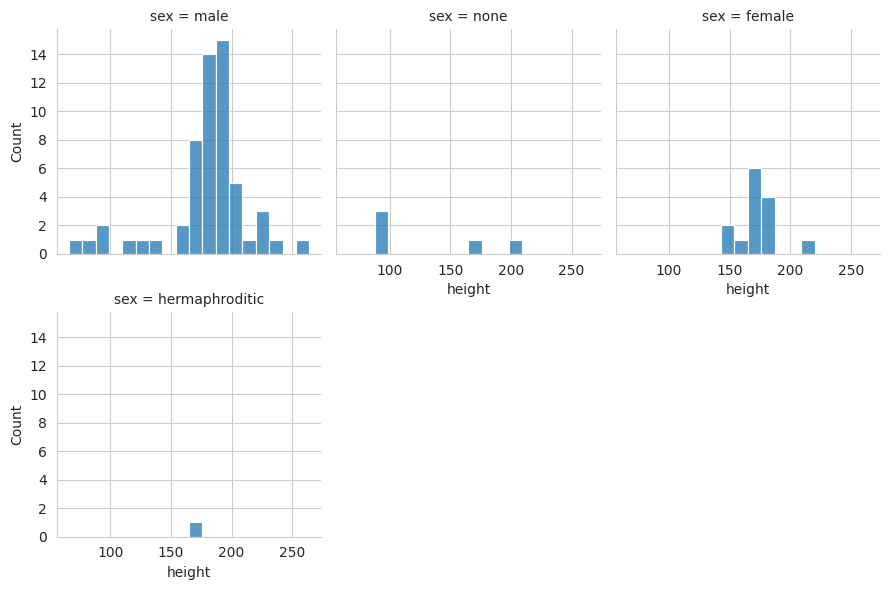

In [21]:
sns.displot(data=starwars, x="height", col="sex", col_wrap=3, height=3)

---
## Trend Lines

Add trend lines to scatter plots using `sns.regplot()` to visualize relationships.

<Axes: xlabel='height', ylabel='mass'>

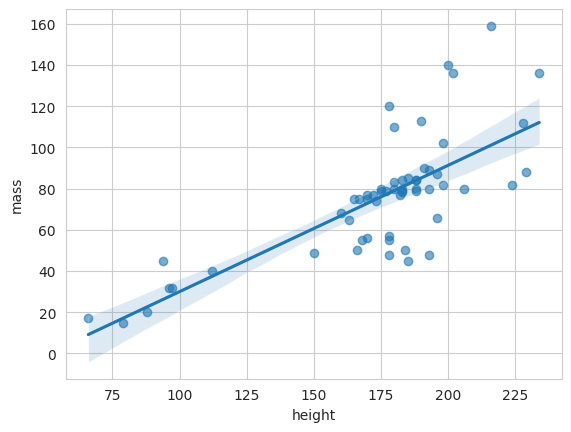

In [22]:
sns.regplot(data=starwars_filtered, x="height", y="mass", scatter_kws={"alpha": 0.6})

Use `sns.lmplot()` to add trend lines grouped by a category.

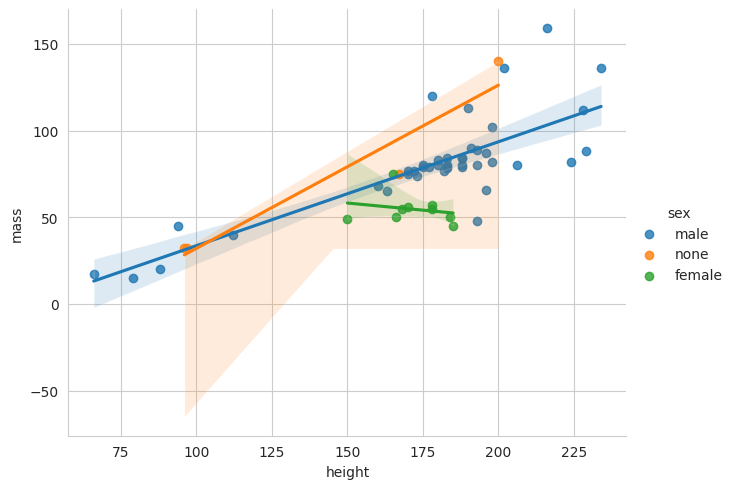

In [24]:
sns.lmplot(data=starwars_filtered, x="height", y="mass", hue="sex", height=5, aspect=1.3)

---
## Pair Plots

Pair plots show relationships between multiple variables at once. Use them to explore your data.

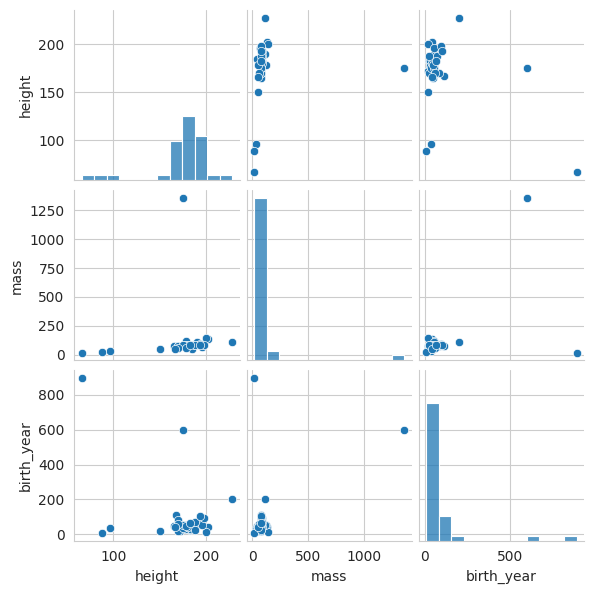

In [27]:
cols_to_plot = ["height", "mass", "birth_year"]
sns.pairplot(starwars[cols_to_plot].dropna(), height=2)

---
## Customizing Plots

You can customize colors, sizes, and other properties using matplotlib functions.

Seaborn has many built-in color palettes.

---
## Summary

| Task | Code |
|------|------|
| Scatter plot | `sns.scatterplot(data=df, x='col1', y='col2')` |
| Scatter with color | `sns.scatterplot(data=df, x='col1', y='col2', hue='col3')` |
| Histogram | `sns.histplot(data=df, x='col')` |
| Density plot | `sns.kdeplot(data=df, x='col')` |
| Bar plot | `sns.countplot(data=df, x='col')` |
| Box plot | `sns.boxplot(data=df, x='cat', y='num')` |
| Trend line | `sns.regplot(data=df, x='col1', y='col2')` |
| Faceting | `sns.relplot(..., col='col')` |
| Pair plot | `sns.pairplot(df[cols])` |
| Labels | `plt.xlabel()`, `plt.ylabel()`, `plt.title()` |
| Show plot | `plt.show()` |

Now you're ready to practice with the visualization exercises!